# 08 · Phase 9 — RL wavelet selection as a multi-armed bandit (24AIM304 Unit 2)

Direct transfer of **Xiao & Wang (PLOS ONE 2025, RLWBS)** from ECG to PCG. They model
wavelet-base selection as a *stateless MDP* and train a policy network with policy gradient,
using classifier accuracy as reward. A stateless MDP is a **k-armed bandit**; its tabular
policy-gradient form is the **gradient bandit** (softmax preferences, REINFORCE with baseline).

* arms: the 5 wavelets; everything else fixed (level 5, 20–800 Hz, 2 s, wavelet branch only)
* pull: sample a training recording → reward = out-of-fold Δ-reward of the arm on that recording
* **non-contextual** (one wavelet for all, K = 1) vs **contextual** (one bandit per signal context)
* algorithms: ε-greedy, UCB1, gradient bandit, Thompson sampling (Gaussian), random
* comparison with the two baselines of the RLWBS paper:
  **CV-WBS** (wavelet with the best cross-validated accuracy) and
  **EE-WBS** (per-signal wavelet maximising the energy-to-Shannon-entropy ratio of its coefficients)

In [1]:
%run ../common/00_config.ipynb
use_half("midsem", oracle="classical")
%run ../common/01_signal_lib.ipynb
%run ../common/02_rl_lib.ipynb
import matplotlib.pyplot as plt
import seaborn as sns

K = load_json(P["results"] / "chosen_K.json")["K"]
prob = RLProblem(CFG, P, K=K)
space = prob.space
A = CFG["actions"]
arms = [space.encode([A["wavelet"].index(w), A["level"].index(5), 4, A["window_s"].index(2.0), A["fusion"].index("W")])
        for w in A["wavelet"]]
print("arms:", [space.label(a) for a in arms], "| K =", K)

CirCor version 1.0.3
midsem: results -> results/midsem/ | reward oracle: classical


loaded 01_signal_lib


loaded 02_rl_lib


arms: ['db4-L5-20-800Hz-2.0s-W', 'db6-L5-20-800Hz-2.0s-W', 'db8-L5-20-800Hz-2.0s-W', 'sym4-L5-20-800Hz-2.0s-W', 'coif3-L5-20-800Hz-2.0s-W'] | K = 8


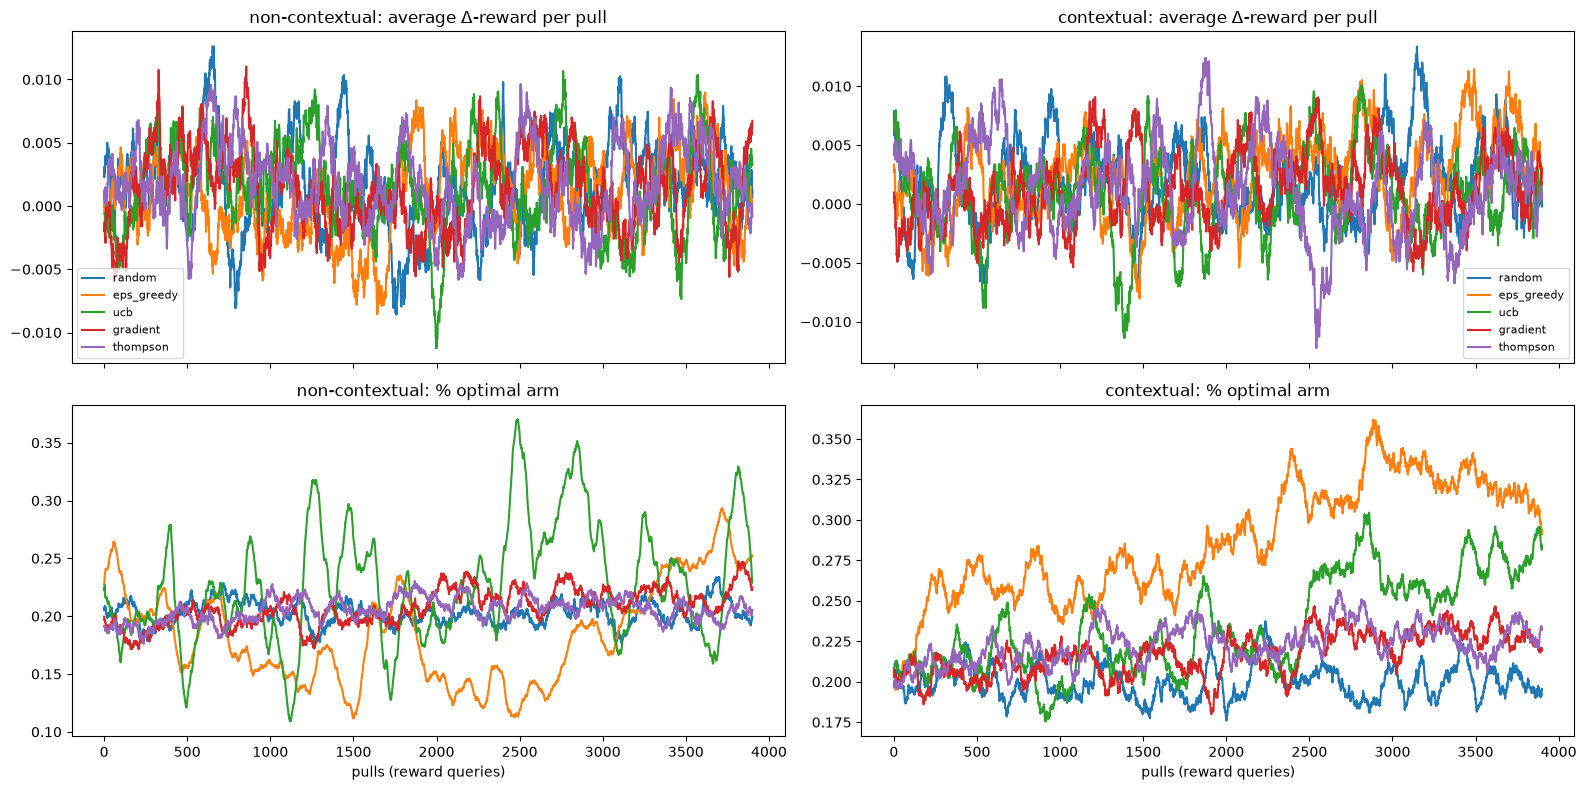

In [2]:
STEPS, SEEDS = 4000, 20
algos = {"random": {}, "eps_greedy": {"epsilon": 0.1}, "ucb": {"c": 0.3}, "gradient": {"alpha": 0.2}, "thompson": {"prior_var": 0.1, "noise_var": 0.3}}
results = {}
for ctx_mode, KK in (("non-contextual", 1), ("contextual", K)):
    ctx_tr = np.zeros_like(prob.ctx["train"]) if KK == 1 else prob.ctx["train"]
    for name, hp in algos.items():
        runs = []
        for s in range(SEEDS):
            rng = np.random.default_rng(s)
            env = BanditEnv(prob.R["train"], ctx_tr, arms, KK, rng)
            runs.append(run_bandit(env, name, STEPS, rng, **hp))
        results[(ctx_mode, name)] = runs


def smooth(v, w=100):
    return np.convolve(v, np.ones(w) / w, mode="valid")


fig, ax = plt.subplots(2, 2, figsize=(16, 8), sharex=True)
for j, ctx_mode in enumerate(("non-contextual", "contextual")):
    for name in algos:
        runs = results[(ctx_mode, name)]
        ax[0, j].plot(smooth(np.mean([r["rewards"] for r in runs], 0)), label=name)
        ax[1, j].plot(smooth(np.mean([r["optimal"] for r in runs], 0)), label=name)
    ax[0, j].set_title(f"{ctx_mode}: average Δ-reward per pull"); ax[1, j].set_title(f"{ctx_mode}: % optimal arm")
    ax[1, j].set_xlabel("pulls (reward queries)"); ax[0, j].legend(fontsize=8)
plt.tight_layout(); savefig(fig, "08_bandit_learning_curves"); plt.show()

## Resulting wavelet policies on the validation split (proxy classifier)

In [3]:
rows = []
for (ctx_mode, name), runs in results.items():
    for s, r in enumerate(runs[:5]):
        pol = r["policy_config"]
        polK = np.full(K, pol[0]) if len(pol) == 1 else pol
        m = prob.evaluate(polK, "val")
        rows.append({"mode": ctx_mode, "algorithm": name, "seed": s, **{k: m[k] for k in ("mean_reward", "macro_f1", "balanced_acc", "auroc")},
                     "wavelets": ",".join(A["wavelet"][arms.index(c)] for c in polK)})
bt = pd.DataFrame(rows)
summary = bt.groupby(["mode", "algorithm"])[["mean_reward", "macro_f1", "balanced_acc", "auroc"]].agg(["mean", "std"]).round(4)
summary

mean_reward         macro_f1         balanced_acc           auroc        
                                 mean     std     mean     std         mean     std    mean     std
mode           algorithm                                                                           
contextual     eps_greedy     -0.0042  0.0031   0.6038  0.0054       0.6402  0.0084  0.6891  0.0062
               gradient       -0.0002  0.0027   0.6042  0.0046       0.6405  0.0077  0.7006  0.0076
               random         -0.0051  0.0048   0.6062  0.0088       0.6413  0.0101  0.6849  0.0161
               thompson       -0.0043  0.0013   0.5999  0.0100       0.6340  0.0096  0.6889  0.0047
               ucb            -0.0021  0.0032   0.6065  0.0137       0.6440  0.0101  0.6974  0.0078
non-contextual eps_greedy     -0.0024  0.0030   0.6000  0.0065       0.6381  0.0103  0.6940  0.0071
               gradient       -0.0010  0.0027   0.6027  0.0081       0.6427  0.0094  0.6974  0.0071
               random         -0.0028  0.0046   0.6066  0.0062       0.6462  0.0039  0.6916  0.0138
               thompson       -0.0028  0.0037   0.6018  0.0070       0.6414  0.0084  0.6919  0.0103
               ucb            -0.0064  0.0013   0.6015  0.0049       0.6340  0.0089  0.6831  0.0056

In [4]:
cv_scores = [binary_metrics(prob.y["train"], prob.p["train"]["clean"][a])["balanced_acc"] for a in arms]
cv_arm = arms[int(np.argmax(cv_scores))]

meta = prob.meta
sig = np.load(P["segments"] / "signals.npz")


def ee_ratio(x, wv):
    M = wavelet_packet_matrix(x[: (len(x) // 32) * 32], wv, 5)
    e = (M ** 2).sum(1)
    p = e / e.sum()
    return e.sum() / (-(p * np.log(p + 1e-12)).sum())


ee_choice = {}
for s in ("val", "test"):
    ids = meta.record_id.values[prob.idx[s]]
    ee_choice[s] = np.array([arms[int(np.argmax([ee_ratio(sig[r].astype(np.float32), w) for w in A["wavelet"]]))] for r in ids])


def eval_per_record(configs, split):
    p = prob.p[split]["clean"][configs, np.arange(len(configs))]
    return binary_metrics(prob.y[split], p)


best = bt[bt["mode"] == "contextual"].groupby("algorithm").mean_reward.mean().idxmax()
best_runs = results[("contextual", best)]
val_scores = [prob.evaluate(r["policy_config"], "val")["mean_reward"] for r in best_runs]
rl_pol = best_runs[int(np.argmax(val_scores))]["policy_config"]
cmp_rows = []
for nm, fn in [("fixed db6", lambda s: np.full(len(prob.y[s]), arms[A["wavelet"].index("db6")])),
               ("CV-WBS (best CV wavelet)", lambda s: np.full(len(prob.y[s]), cv_arm)),
               ("EE-WBS (energy/entropy per signal)", lambda s: ee_choice[s]),
               (f"RL contextual bandit ({best})", lambda s: np.asarray(rl_pol)[prob.ctx[s]])]:
    for s in ("val", "test"):
        m = eval_per_record(fn(s), s)
        cmp_rows.append({"method": nm, "split": s, **{k: m[k] for k in ("macro_f1", "sensitivity", "specificity", "balanced_acc", "auroc", "auprc")}})
cmp = pd.DataFrame(cmp_rows)
cmp.to_csv(P["tables"] / "08_wavelet_selection_comparison.csv", index=False)
cmp.pivot(index="method", columns="split", values=["macro_f1", "balanced_acc", "auroc"]).round(3)

macro_f1        balanced_acc         auroc       
split                                  test    val         test    val   test    val
method                                                                              
CV-WBS (best CV wavelet)              0.562  0.611        0.628  0.650  0.641  0.704
EE-WBS (energy/entropy per signal)    0.581  0.606        0.647  0.646  0.669  0.690
RL contextual bandit (gradient)       0.576  0.610        0.650  0.646  0.657  0.710
fixed db6                             0.564  0.609        0.630  0.652  0.666  0.704

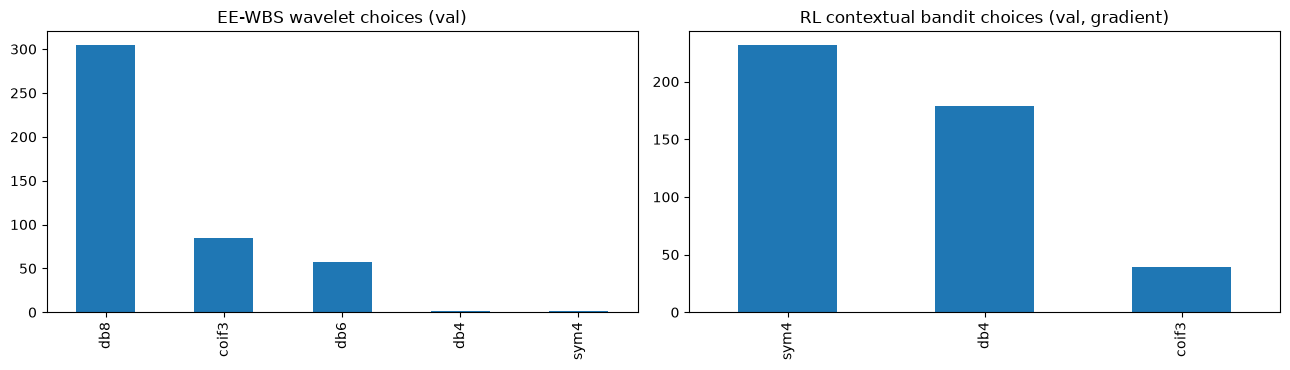

{'algorithm': 'gradient',
 'K': 8,
 'policy_config': [1668, 1668, 408, 2088, 408, 1668, 2088, 1668],
 'wavelets': ['sym4', 'sym4', 'db4', 'coif3', 'db4', 'sym4', 'coif3', 'sym4']}

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
pd.Series([A["wavelet"][arms.index(c)] for c in ee_choice["val"]]).value_counts().plot.bar(ax=ax[0], title="EE-WBS wavelet choices (val)")
pd.Series([A["wavelet"][arms.index(c)] for c in np.asarray(rl_pol)[prob.ctx["val"]]]).value_counts().plot.bar(ax=ax[1], title=f"RL contextual bandit choices (val, {best})")
plt.tight_layout(); savefig(fig, "08_wavelet_choices"); plt.show()
policy_out = {"algorithm": best, "K": K, "policy_config": [int(c) for c in rl_pol],
              "wavelets": [A["wavelet"][arms.index(c)] for c in rl_pol]}
save_json(policy_out, P["results"] / "policies" / "rl_wavelet_only.json")
policy_out